In [2]:
#importing pandas
import pandas as pd
import numpy as np

In [3]:
#loading the datasets
df_2019 = pd.read_csv("data/2019_LoL_esports_match_data_from_OraclesElixir.csv")
df_2022 = pd.read_csv("data/2022_LoL_esports_match_data_from_OraclesElixir.csv")
df_2025 = pd.read_csv("data/2025_LoL_esports_match_data_from_OraclesElixir.csv")

C:\Users\georg\AppData\Local\Temp\ipykernel_21020\1097218941.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2022 = pd.read_csv("data/2022_LoL_esports_match_data_from_OraclesElixir.csv")
C:\Users\georg\AppData\Local\Temp\ipykernel_21020\1097218941.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025 = pd.read_csv("data/2025_LoL_esports_match_data_from_OraclesElixir.csv")


In [4]:


cols = [
    "year", "league", "teamname", "result", "position", "side",
    "goldat15", "xpat15", "csat15",
    "opp_goldat15", "opp_xpat15", "opp_csat15",
    "golddiffat15", "xpdiffat15", "csdiffat15",
    "killsat15", "assistsat15", "deathsat15",
    "opp_killsat15", "opp_assistsat15", "opp_deathsat15",
    "gamelength", "patch", "date",
    "firstherald", "firstbaron", "firsttower",
    "firstmidtower", "firsttothreetowers",
    "barons", "heralds", "inhibitors",
    "firstblood", "firstdragon",
    "dragons", "elders"
]

df_2019_clean = df_2019.reindex(columns=cols).copy()
df_2022_clean = df_2022.reindex(columns=cols).copy()
df_2025_clean = df_2025.reindex(columns=cols).copy()

df = pd.concat([df_2019_clean, df_2022_clean, df_2025_clean], ignore_index=True)

# Filter to team rows ONLY
df = df[df["position"] == "team"]

# Keep only 2019, 2022, 2025
df = df[df["year"].isin([2019, 2022, 2025])]

# ONLY drop rows missing the absolute essentials — not all objective columns
df = df.dropna(subset=["result", "league", "year", "golddiffat15"])

print("Years present:")
print(df["year"].value_counts().sort_index())
print(f"\nTotal team rows: {len(df)}")

Years present:
year
2019    15560
2022    20344
2025    17978
Name: count, dtype: int64

Total team rows: 53882


In [5]:
# Recreate every derived column in one place , SAME AS ABOVE CELL!
df["got_inhibitor"] = (df["inhibitors"] >= 1).astype(int)
df["gold_lead"] = (df["golddiffat15"] > 0).astype(int)
df["xp_lead"] = (df["xpdiffat15"] > 0).astype(int)
df["dragon_soul"] = (df["dragons"] >= 4).astype(int)

bins = [-np.inf, -3000, -1000, 0, 1000, 3000, np.inf]
labels = ["big deficit", "deficit", "even", "small lead", "lead", "big lead"]
df["gold_bucket"] = pd.cut(df["golddiffat15"], bins=bins, labels=labels)

length_bins = [0, 1500, 1800, 2100, 2400, np.inf]
length_labels = ["<25min", "25-30min", "30-35min", "35-40min", "40min+"]
df["length_bucket"] = pd.cut(df["gamelength"], bins=length_bins, labels=length_labels)

df_main = df[df["league"].isin(["LCK", "LPL", "LEC", "LCS", "PCS"])]
comebacks_main = df_main[(df_main["golddiffat15"] > 1000) & (df_main["result"] == 0)]

In [6]:
#exploring the dataset
early_cols = [c for c in df_2019.columns if "diffat" in c or "at15" in c or "at25" in c]
early_cols

['golddiffat10',
 'xpdiffat10',
 'csdiffat10',
 'goldat15',
 'xpat15',
 'csat15',
 'opp_goldat15',
 'opp_xpat15',
 'opp_csat15',
 'golddiffat15',
 'xpdiffat15',
 'csdiffat15',
 'killsat15',
 'assistsat15',
 'deathsat15',
 'opp_killsat15',
 'opp_assistsat15',
 'opp_deathsat15',
 'golddiffat20',
 'xpdiffat20',
 'csdiffat20',
 'goldat25',
 'xpat25',
 'csat25',
 'opp_goldat25',
 'opp_xpat25',
 'opp_csat25',
 'golddiffat25',
 'xpdiffat25',
 'csdiffat25',
 'killsat25',
 'assistsat25',
 'deathsat25',
 'opp_killsat25',
 'opp_assistsat25',
 'opp_deathsat25']

In [7]:
#exploring the dataset
early_cols = [c for c in df_2022.columns if "diffat" in c or "at15" in c or "at25" in c]
early_cols

['golddiffat10',
 'xpdiffat10',
 'csdiffat10',
 'goldat15',
 'xpat15',
 'csat15',
 'opp_goldat15',
 'opp_xpat15',
 'opp_csat15',
 'golddiffat15',
 'xpdiffat15',
 'csdiffat15',
 'killsat15',
 'assistsat15',
 'deathsat15',
 'opp_killsat15',
 'opp_assistsat15',
 'opp_deathsat15',
 'golddiffat20',
 'xpdiffat20',
 'csdiffat20',
 'goldat25',
 'xpat25',
 'csat25',
 'opp_goldat25',
 'opp_xpat25',
 'opp_csat25',
 'golddiffat25',
 'xpdiffat25',
 'csdiffat25',
 'killsat25',
 'assistsat25',
 'deathsat25',
 'opp_killsat25',
 'opp_assistsat25',
 'opp_deathsat25']

In [8]:
#exploring the dataset
early_cols = [c for c in df_2025.columns if "diffat" in c or "at15" in c or "at25" in c]
early_cols

['golddiffat10',
 'xpdiffat10',
 'csdiffat10',
 'goldat15',
 'xpat15',
 'csat15',
 'opp_goldat15',
 'opp_xpat15',
 'opp_csat15',
 'golddiffat15',
 'xpdiffat15',
 'csdiffat15',
 'killsat15',
 'assistsat15',
 'deathsat15',
 'opp_killsat15',
 'opp_assistsat15',
 'opp_deathsat15',
 'golddiffat20',
 'xpdiffat20',
 'csdiffat20',
 'goldat25',
 'xpat25',
 'csat25',
 'opp_goldat25',
 'opp_xpat25',
 'opp_csat25',
 'golddiffat25',
 'xpdiffat25',
 'csdiffat25',
 'killsat25',
 'assistsat25',
 'deathsat25',
 'opp_killsat25',
 'opp_assistsat25',
 'opp_deathsat25']

In [9]:
#exploring the data
set(df_2019.columns)
set(df_2022.columns)
set(df_2025.columns)

{'assists',
 'assistsat10',
 'assistsat15',
 'assistsat20',
 'assistsat25',
 'atakhans',
 'ban1',
 'ban2',
 'ban3',
 'ban4',
 'ban5',
 'barons',
 'champion',
 'chemtechs',
 'ckpm',
 'clouds',
 'controlwardsbought',
 'csat10',
 'csat15',
 'csat20',
 'csat25',
 'csdiffat10',
 'csdiffat15',
 'csdiffat20',
 'csdiffat25',
 'cspm',
 'damagemitigatedperminute',
 'damageshare',
 'damagetakenperminute',
 'damagetochampions',
 'damagetotowers',
 'datacompleteness',
 'date',
 'deaths',
 'deathsat10',
 'deathsat15',
 'deathsat20',
 'deathsat25',
 'doublekills',
 'dpm',
 'dragons',
 'dragons (type unknown)',
 'earned gpm',
 'earnedgold',
 'earnedgoldshare',
 'elders',
 'elementaldrakes',
 'firstPick',
 'firstbaron',
 'firstblood',
 'firstbloodassist',
 'firstbloodkill',
 'firstbloodvictim',
 'firstdragon',
 'firstherald',
 'firstmidtower',
 'firsttothreetowers',
 'firsttower',
 'game',
 'gameid',
 'gamelength',
 'goldat10',
 'goldat15',
 'goldat20',
 'goldat25',
 'golddiffat10',
 'golddiffat15',
 '

In [10]:
#existence check 
[col for col in ["golddiffat15", "xpdiffat15", "csdiffat15", "result", "year", "league"] if col in df.columns]

['golddiffat15', 'xpdiffat15', 'csdiffat15', 'result', 'year', 'league']

In [11]:
#overall correlation between early - game stats
# gold difference is the bigger predictor FOR NOW at 0.35.6 => 0.36
df[["golddiffat15", "xpdiffat15", "csdiffat15", "result"]].corr()["result"].sort_values(ascending=False)

result          1.000000
golddiffat15    0.536788
xpdiffat15      0.501828
csdiffat15      0.420336
Name: result, dtype: float64

In [12]:
#year by year correlations , show stability across seasons
#this is how we adress the hypothesis, "does importance change across seasons
for y in df["year"].unique():
    sub = df[df["year"] == y]
    print(f"\nYear {y}")
    print(sub[["golddiffat15", "xpdiffat15", "csdiffat15", "result"]].corr()["result"])


Year 2019
golddiffat15    0.556384
xpdiffat15      0.523619
csdiffat15      0.413456
result          1.000000
Name: result, dtype: float64

Year 2022
golddiffat15    0.538155
xpdiffat15      0.493541
csdiffat15      0.404942
result          1.000000
Name: result, dtype: float64

Year 2025
golddiffat15    0.522826
xpdiffat15      0.492497
csdiffat15      0.449675
result          1.000000
Name: result, dtype: float64


In [13]:
#Regional correlations which show PCS is the most consistent and LCS most volatile
# This adresses the hypothesis " do regions show different patterns? 
main_regions = ["LCK", "LPL", "LEC", "LCS", "PCS"]
df_main = df[df["league"].isin(main_regions)]

for region in df_main["league"].unique():
    sub = df_main[df_main["league"] == region]
    print(f"\nRegion: {region}")
    print(sub[["golddiffat15", "xpdiffat15", "csdiffat15", "result"]].corr()["result"])


Region: LPL
golddiffat15    0.539987
xpdiffat15      0.506884
csdiffat15      0.358281
result          1.000000
Name: result, dtype: float64

Region: LCK
golddiffat15    0.512999
xpdiffat15      0.462685
csdiffat15      0.370573
result          1.000000
Name: result, dtype: float64

Region: LEC
golddiffat15    0.484832
xpdiffat15      0.450493
csdiffat15      0.331026
result          1.000000
Name: result, dtype: float64

Region: LCS
golddiffat15    0.469264
xpdiffat15      0.417157
csdiffat15      0.240996
result          1.000000
Name: result, dtype: float64

Region: PCS
golddiffat15    0.640828
xpdiffat15      0.607468
csdiffat15      0.550419
result          1.000000
Name: result, dtype: float64


In [14]:
# This is where we check the comebacks
#Comeback means when a team had 1000+ gold lead at 15 minutes but lost the match
comebacks = df[(df["golddiffat15"] > 1000) & (df["result"] == 0)]
len(comebacks)

3607

In [15]:
#Here we filter comebacks to the 5 main regions for cleaner regional comparison
main_regions = ["LCK", "LPL", "LEC", "LCS", "PCS"]
df_main = df[df["league"].isin(main_regions)]
comebacks_main = comebacks[comebacks["league"].isin(main_regions)]
len(comebacks_main)
comebacks_main["league"].value_counts()

league
LCK    189
LEC    113
LPL     88
LCS     81
PCS     51
Name: count, dtype: int64

In [16]:
#Comeback rate by region > we see that LPL teams throw(throw away their leads) most of their games , PCS throw the least.
total_games_by_region = df_main["league"].value_counts()
comeback_rate = comebacks_main["league"].value_counts() / total_games_by_region
comeback_rate

league
LCK    0.062916
LCS    0.073503
LEC    0.071883
LPL    0.069841
PCS    0.044271
Name: count, dtype: float64

In [17]:
#we see the comeback frequency by year. 
comebacks_by_year = comebacks_main["year"].value_counts().sort_index()
comebacks_by_year

year
2019    224
2022    167
2025    131
Name: count, dtype: int64

In [18]:
#Bucketing comebacks by lead size , most comebacks happen at 1k-2k leads 
import numpy as np

bins = [1000, 2000, 3000, 4000, 5000, np.inf]
labels = ["1k–2k", "2k–3k", "3k–4k", "4k–5k", "5k+"]

comebacks_main["lead_bucket"] = pd.cut(comebacks_main["golddiffat15"], bins=bins, labels=labels)

comebacks_main["lead_bucket"].value_counts().sort_index()

C:\Users\georg\AppData\Local\Temp\ipykernel_21020\2554180939.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comebacks_main["lead_bucket"] = pd.cut(comebacks_main["golddiffat15"], bins=bins, labels=labels)


lead_bucket
1k–2k    318
2k–3k    122
3k–4k     58
4k–5k     18
5k+        6
Name: count, dtype: int64

In [19]:
#lead distribution by region 
comebacks_main.groupby("league")["lead_bucket"].value_counts().sort_index()

league  lead_bucket
LCK     1k–2k          126
        2k–3k           47
        3k–4k           11
        4k–5k            4
        5k+              1
LCS     1k–2k           49
        2k–3k           14
        3k–4k           12
        4k–5k            2
        5k+              4
LEC     1k–2k           57
        2k–3k           35
        3k–4k           14
        4k–5k            6
        5k+              1
LPL     1k–2k           53
        2k–3k           13
        3k–4k           18
        4k–5k            4
        5k+              0
PCS     1k–2k           33
        2k–3k           13
        3k–4k            3
        4k–5k            2
        5k+              0
Name: count, dtype: int64

In [20]:
#statistical summary of gold leads that got thrown - average = 1638
comebacks_main["golddiffat15"].describe()

count     522.000000
mean     2022.685824
std       976.244747
min      1002.000000
25%      1280.250000
50%      1713.500000
75%      2446.250000
max      8025.000000
Name: golddiffat15, dtype: float64

In [21]:
#Average thrown lead by region , LCS throws biggest leads on average > why this happens?
comebacks_main.groupby("league")["golddiffat15"].mean()

league
LCK    1881.216931
LCS    2161.617284
LEC    2164.053097
LPL    2095.704545
PCS    1887.078431
Name: golddiffat15, dtype: float64

In [22]:
#The length of the games that the comebacks happen - average 35min
comebacks_main["gamelength"].describe()

count     522.000000
mean     2166.515326
std       348.967290
min      1260.000000
25%      1918.000000
50%      2129.000000
75%      2379.250000
max      3558.000000
Name: gamelength, dtype: float64

In [23]:
#Game length stats for ALL games , aver - 32.7 min
#Comebacks happen in longer games, this means if a team wants to comeback they have to stretch the game
#Time = losing team comeback factor? 
df_main["gamelength"].describe()

count    8090.000000
mean     1962.613103
std       343.795800
min      1111.000000
25%      1716.000000
50%      1916.000000
75%      2161.000000
max      3558.000000
Name: gamelength, dtype: float64

In [24]:
#Average comeback game length by region
comebacks_main.groupby("league")["gamelength"].mean()

league
LCK    2197.746032
LCS    2176.901235
LEC    2200.938053
LPL    2092.113636
PCS    2086.392157
Name: gamelength, dtype: float64

In [25]:
#winrate per major objective - baron and inhibitor are decisive - herald good statistic but not a priority!
objectives = ["firstherald", "firstbaron", "got_inhibitor"]

for obj in objectives:
    wr = df.groupby(obj)["result"].mean()
    print(f"\n{obj}:\n{wr}")


firstherald:
firstherald
0.0    0.384763
1.0    0.615880
Name: result, dtype: float64

firstbaron:
firstbaron
0.0    0.205223
1.0    0.854277
Name: result, dtype: float64

got_inhibitor:
got_inhibitor
0    0.011521
1    0.931069
Name: result, dtype: float64


In [26]:
# Objective win rates broken down by region and by year  
for obj in ["firstherald", "firstbaron", "got_inhibitor"]:
    print(f"\n=== {obj} win rate by league ===")
    print(df_main.groupby(["league", obj])["result"].mean().unstack())

# By year
for obj in ["firstherald", "firstbaron", "got_inhibitor"]:
    print(f"\n=== {obj} win rate by year ===")
    print(df.groupby(["year", obj])["result"].mean().unstack())


=== firstherald win rate by league ===
firstherald       0.0       1.0
league                         
LCK          0.402123  0.598530
LCS          0.434705  0.567219
LEC          0.390368  0.610473
LPL          0.452532  0.547923
PCS          0.347751  0.653310

=== firstbaron win rate by league ===
firstbaron       0.0       1.0
league                        
LCK         0.204988  0.856618
LCS         0.177193  0.845865
LEC         0.203290  0.850208
LPL         0.152284  0.847716
PCS         0.241228  0.878205

=== got_inhibitor win rate by league ===
got_inhibitor         0         1
league                           
LCK            0.000711  0.939299
LCS            0.000000  0.932318
LEC            0.000000  0.930178
LPL            0.005042  0.942857
PCS            0.000000  0.961603

=== firstherald win rate by year ===
firstherald       0.0       1.0
year                           
2019         0.398800  0.602589
2022         0.417690  0.582358
2025         0.335369  0.665329

=

In [27]:
#first link in casual chain > gold lead doubles the baron rate (62.5%>27.9%)
df["gold_lead"] = (df["golddiffat15"] > 0).astype(int)
df.groupby("gold_lead")["firstbaron"].mean()

gold_lead
0    0.278097
1    0.630245
Name: firstbaron, dtype: float64

In [28]:
#gold buckets that show that baron rate and win rate scale together with gold lead
bins = [-np.inf, -3000, -1000, 0, 1000, 3000, np.inf]
labels = ["big deficit", "deficit", "even", "small lead", "lead", "big lead"]
df["gold_bucket"] = pd.cut(df["golddiffat15"], bins=bins, labels=labels)

df.groupby("gold_bucket")[["firstbaron", "result"]].mean()

C:\Users\georg\AppData\Local\Temp\ipykernel_21020\3145662677.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("gold_bucket")[["firstbaron", "result"]].mean()


,firstbaron,result
gold_bucket,,
big deficit,0.121288,0.079199
deficit,0.283824,0.262519
even,0.421180,0.426209
small lead,0.525217,0.573935
lead,0.646481,0.737546
big lead,0.714701,0.920870


In [29]:
#The single most important finding
#Gold lead alone wins 0.44% of the game BUT gold lead WITH baron wins 0.918% of the games 
#Baron is the conversion mechanism , not just a side-effect
df.groupby(["gold_lead", "firstbaron"])["result"].mean().unstack()

firstbaron,0.0,1.0
gold_lead,,
0,0.085738,0.708294
1,0.438520,0.918697


In [30]:
# Teams ahead in gold at 15
ahead = df[df["golddiffat15"] > 1000]

print("Win rate when ahead AND got baron:")
print(ahead[ahead["firstbaron"] == 1]["result"].mean())

print("Win rate when ahead but NO baron:")
print(ahead[ahead["firstbaron"] == 0]["result"].mean())

Win rate when ahead AND got baron:
0.9365811698467313
Win rate when ahead but NO baron:
0.54972554084598


In [31]:
# More gold at 15 = more kills (proxy for winning fights)
df[["golddiffat15", "killsat15"]].corr()

,golddiffat15,killsat15
golddiffat15,1.000000,0.523255
killsat15,0.523255,1.000000


In [32]:
#Ranking ALL early indicators by individual winrate
#Tower - based objectives outperform first blood and first dragon
early_indicators = [
    "firstblood", "firsttower", "firstherald",
    "firstmidtower", "firsttothreetowers", "firstdragon"
]

results = {}
for col in early_indicators:
    wr = df.groupby(col)["result"].mean()
    if 1.0 in wr.index:
        results[col] = wr[1.0]

ranking = pd.Series(results).sort_values(ascending=False)
print(ranking)

firsttothreetowers    0.786828
firstmidtower         0.738649
firsttower            0.694587
firstherald           0.615880
firstdragon           0.598396
firstblood            0.597177
dtype: float64


In [33]:
#combined early score (0-5) - wins scale almost linearly with the score
# The numbers prove that early dominance is collectively decisive 
df["early_score"] = (
    df["firstblood"].fillna(0) +
    df["firsttower"].fillna(0) +
    df["firstherald"].fillna(0) +
    df["firstdragon"].fillna(0) +
    df["gold_lead"].fillna(0)  # already created
)

df.groupby("early_score")["result"].mean()

early_score
0.0    0.137294
1.0    0.244474
2.0    0.390366
3.0    0.610580
4.0    0.756171
5.0    0.862929
Name: result, dtype: float64

In [34]:
#gold lead value decays over time - 97% before 25 miin , 58% by 35-40
bins = [0, 1500, 1800, 2100, 2400, np.inf]
labels = ["<25min", "25-30min", "30-35min", "35-40min", "40min+"]
df["length_bucket"] = pd.cut(df["gamelength"], bins=bins, labels=labels)

df.groupby(["length_bucket", "gold_lead"])["result"].mean().unstack()


C:\Users\georg\AppData\Local\Temp\ipykernel_21020\137362662.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["length_bucket", "gold_lead"])["result"].mean().unstack()


gold_lead,0,1
length_bucket,,
<25min,0.029583,0.970417
25-30min,0.144795,0.855286
30-35min,0.293414,0.706586
35-40min,0.399410,0.600590
40min+,0.476466,0.523534


In [35]:
#kill lead at 15 translates to all structural objectives and gold 
#we see that skill in the game - getting kills, actually matters, and personal performance of a player matters > more kills > 
#more structures > more gold
df["kill_lead"] = (df["killsat15"] > df["opp_killsat15"]).astype(int)

df.groupby("kill_lead")[["firsttower", "firstmidtower", 
                          "firstherald", "firsttothreetowers",
                          "golddiffat15"]].mean()

,firsttower,firstmidtower,firstherald,firsttothreetowers,golddiffat15
kill_lead,,,,,
0,0.349952,0.327487,0.396795,0.312177,-1699.142697
1,0.694119,0.723228,0.630349,0.742816,2198.562902


In [36]:
#false positive rates per indicator - First blood and first dragon are the most unreliable - also first herald by a small difference 
early_indicators = [
    "firstblood", "firsttower", "firstherald",
    "firstmidtower", "firsttothreetowers", "firstdragon",
    "firstbaron", "got_inhibitor", "gold_lead"
]

fp_results = {}
for col in early_indicators:
    # Teams that HAD the advantage
    had_advantage = df[df[col] == 1]
    # But lost
    false_positives = had_advantage[had_advantage["result"] == 0]
    
    fp_rate = len(false_positives) / len(had_advantage)
    fp_results[col] = fp_rate

fp_ranking = pd.Series(fp_results).sort_values(ascending=False)
print(fp_ranking)

firstblood            0.402823
firstdragon           0.401604
firstherald           0.384120
firsttower            0.305413
firstmidtower         0.261351
gold_lead             0.258278
firsttothreetowers    0.213172
firstbaron            0.145723
got_inhibitor         0.068931
dtype: float64


In [37]:
#false positive rates by region - PCS converts advantages most reliably 
for col in ["firstblood", "firsttower", "firstbaron", "gold_lead"]:
    print(f"\n=== {col} false positive rate by region ===")
    for region in ["LCK", "LPL", "LEC", "LCS", "PCS"]:
        sub = df_main[df_main["league"] == region]
        had = sub[sub[col] == 1]
        fp = had[had["result"] == 0]
        rate = len(fp) / len(had) if len(had) > 0 else 0
        print(f"{region}: {rate:.3f}")


=== firstblood false positive rate by region ===
LCK: 0.405
LPL: 0.423
LEC: 0.410
LCS: 0.448
PCS: 0.356

=== firsttower false positive rate by region ===
LCK: 0.323
LPL: 0.332
LEC: 0.336
LCS: 0.336
PCS: 0.259

=== firstbaron false positive rate by region ===
LCK: 0.143
LPL: 0.152
LEC: 0.150
LCS: 0.154
PCS: 0.122

=== gold_lead false positive rate by region ===
LCK: 0.276
LPL: 0.256
LEC: 0.282
LCS: 0.278
PCS: 0.205


In [38]:
#false positive rate by year , sligth downward trend over time 
for col in ["firstblood", "firsttower", "firstbaron", "gold_lead"]:
    print(f"\n=== {col} false positive rate by year ===")
    for year in sorted(df["year"].unique()):
        sub = df[df["year"] == year]
        had = sub[sub[col] == 1]
        fp = had[had["result"] == 0]
        rate = len(fp) / len(had) if len(had) > 0 else 0
        print(f"{year}: {rate:.3f}")


=== firstblood false positive rate by year ===
2019: 0.394
2022: 0.391
2025: 0.424

=== firsttower false positive rate by year ===
2019: 0.297
2022: 0.317
2025: 0.299

=== firstbaron false positive rate by year ===
2019: 0.139
2022: 0.151
2025: 0.146

=== gold_lead false positive rate by year ===
2019: 0.244
2022: 0.257
2025: 0.272


In [39]:
#even teams that win all 5 early indicators still lose 13.5% of the time 
for score in range(6):
    had = df[df["early_score"] == score]
    # For scores > 2, we expect wins — false positives are losses
    fp = had[had["result"] == 0]
    rate = len(fp) / len(had) if len(had) > 0 else 0
    print(f"Early score {score}/5 → lost anyway: {rate:.3f} ({len(fp)} games)")

Early score 0/5 → lost anyway: 0.863 (5184 games)
Early score 1/5 → lost anyway: 0.756 (7998 games)
Early score 2/5 → lost anyway: 0.610 (6328 games)
Early score 3/5 → lost anyway: 0.389 (4034 games)
Early score 4/5 → lost anyway: 0.244 (2578 games)
Early score 5/5 → lost anyway: 0.137 (819 games)


In [40]:
# Had gold lead AND baron but still lost
#Almost all of those happened in games over 35 minutes > coming back again to time - good factor for losing teams
fp_chain = df[
    (df["gold_lead"] == 1) &
    (df["firstbaron"] == 1) &
    (df["result"] == 0)
]

print(f"Total false positives (gold lead + baron but lost): {len(fp_chain)}")
print(f"False positive rate: {len(fp_chain) / len(df[df['gold_lead']==1][df['firstbaron']==1]):.3f}")

# Break down by region
print(fp_chain["league"].value_counts())

# Break down by year  
print(fp_chain["year"].value_counts())

# How long did these games go?
print(fp_chain["gamelength"].describe())

Total false positives (gold lead + baron but lost): 1375
False positive rate: 0.081
league
LCK     74
LDL     57
LCKC    54
LCSA    53
LEC     42
        ..
LTA      2
BM       1
USP      1
EWC      1
ASI      1
Name: count, Length: 80, dtype: int64
year
2022    567
2025    415
2019    393
Name: count, dtype: int64
count    1375.000000
mean     2303.128727
std       318.069692
min      1260.000000
25%      2073.000000
50%      2271.000000
75%      2498.500000
max      3509.000000
Name: gamelength, dtype: float64


C:\Users\georg\AppData\Local\Temp\ipykernel_21020\3223869971.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"False positive rate: {len(fp_chain) / len(df[df['gold_lead']==1][df['firstbaron']==1]):.3f}")


In [41]:
#The most extreme false positives - Won every indicator + baron and STILL lost 
# The average game length of those is 38 minutes - confirms time is the universal explanation 
fp_full = df[
    (df["firstblood"] == 1) &
    (df["firsttower"] == 1) &
    (df["firstherald"] == 1) &
    (df["gold_lead"] == 1) &
    (df["firstbaron"] == 1) &
    (df["result"] == 0)
]

print(f"Won every early indicator + baron but still lost: {len(fp_full)} games")
print(f"\nBy region:\n{fp_full['league'].value_counts()}")
print(f"\nBy year:\n{fp_full['year'].value_counts()}")
print(f"\nGame length:\n{fp_full['gamelength'].describe()}")

Won every early indicator + baron but still lost: 426 games

By region:
league
LCK                22
LCSA               20
LEC                19
LDL                17
LCKC               17
                   ..
NASG                1
NLC Aurora Open     1
GLLPA               1
ESLOL               1
ASI                 1
Name: count, Length: 73, dtype: int64

By year:
year
2022    200
2019    123
2025    103
Name: count, dtype: int64

Game length:
count     426.000000
mean     2317.004695
std       312.561937
min      1334.000000
25%      2093.500000
50%      2274.000000
75%      2495.750000
max      3308.000000
Name: gamelength, dtype: float64


In [42]:
#will go back to xp since i never analyzed it , does having xp lead , led to baron? same with gold
#
df["xp_lead"] = (df["xpdiffat15"] > 0).astype(int)


df.groupby(["gold_lead", "xp_lead"])["firstbaron"].mean().unstack()


df.groupby(["gold_lead", "xp_lead"])["result"].mean().unstack()

xp_lead,0,1
gold_lead,,
0,0.215450,0.444533
1,0.555556,0.784660


In [43]:
#cs lead generates gold so its on of the main income of gold which feeds the entire chain. 
df["cs_lead"] = (df["csdiffat15"] > 0).astype(int)
df.groupby("cs_lead")["golddiffat15"].mean()
df.groupby("cs_lead")["result"].mean()

cs_lead
0    0.325416
1    0.677921
Name: result, dtype: float64

In [44]:
#we saw the difference with kills so lets check deaths aswell 
df["kd_ratio_15"] = df["killsat15"] / (df["deathsat15"] + 1)  # +1 avoids division by zero
df[["kd_ratio_15", "golddiffat15", "result"]].corr()

,kd_ratio_15,golddiffat15,result
kd_ratio_15,1.000000,0.658609,0.360054
golddiffat15,0.658609,1.000000,0.536788
result,0.360054,0.536788,1.000000


In [45]:
#first blood has 40% false positive rate , that leads to :
df.groupby("firstblood")["golddiffat15"].mean()

#we see that the gold advantage from only a kill is quickly erased by farming

firstblood
0.0   -1096.749944
1.0    1097.972177
Name: golddiffat15, dtype: float64

In [46]:
# DEEPER ANALYSIS #1: Which specific combinations make up each early score level?
# We know 3/5 wins 61% but is it because of WHICH 3 indicators, not just the count?

indicators = ["firstblood", "firsttower", "firstherald", "firstdragon", "gold_lead"]

# For each meaningful score level, show every combination, count, and win rate
for score in [1, 2, 3, 4]:
    sub = df[df["early_score"] == score].copy()
    
    # Build a label showing which indicators were won
    sub["combo"] = sub[indicators].apply(
        lambda row: " + ".join([c for c in indicators if row[c] == 1]), axis=1
    )
    
    print(f"\n{'='*70}")
    print(f"EARLY SCORE {score}/5 — {len(sub)} games — overall win rate: {sub['result'].mean():.1%}")
    print(f"{'='*70}")
    
    combo_stats = sub.groupby("combo").agg(
        games=("result", "count"),
        win_rate=("result", "mean")
    ).sort_values("win_rate", ascending=False)
    
    print(combo_stats.to_string())


EARLY SCORE 1/5 — 10586 games — overall win rate: 24.4%
             games  win_rate
combo                       
gold_lead      544  0.511029
firsttower     827  0.295042
firstdragon   4309  0.262474
firstherald   2343  0.205719
firstblood    2563  0.176746

EARLY SCORE 2/5 — 10380 games — overall win rate: 39.0%
                           games  win_rate
combo                                     
firstdragon + gold_lead      607  0.665568
firsttower + gold_lead       886  0.620767
firstherald + gold_lead      524  0.547710
firstblood + gold_lead       883  0.509626
firsttower + firstdragon     916  0.443231
firsttower + firstherald    1214  0.332784
firstherald + firstdragon   1325  0.318491
firstblood + firsttower      392  0.313776
firstblood + firstdragon    2377  0.303324
firstblood + firstherald    1256  0.226911

EARLY SCORE 3/5 — 10359 games — overall win rate: 61.1%
                                        games  win_rate
combo                                                 

In [47]:
# At each score level, compare combos WITH gold_lead vs combos WITHOUT
print("=== GOLD LEAD PREMIUM PER SCORE LEVEL ===\n")
for score in [1, 2, 3, 4]:
    sub = df[df["early_score"] == score]
    
    with_gold = sub[sub["gold_lead"] == 1]["result"].mean()
    without_gold = sub[sub["gold_lead"] == 0]["result"].mean()
    
    gap = (with_gold - without_gold) * 100
    print(f"Score {score}/5:")
    print(f"  With gold_lead:    {with_gold:.1%}")
    print(f"  Without gold_lead: {without_gold:.1%}")
    print(f"  GOLD LEAD PREMIUM: +{gap:.1f} percentage points\n")

=== GOLD LEAD PREMIUM PER SCORE LEVEL ===

Score 1/5:
  With gold_lead:    51.1%
  Without gold_lead: 23.0%
  GOLD LEAD PREMIUM: +28.1 percentage points

Score 2/5:
  With gold_lead:    58.3%
  Without gold_lead: 31.6%
  GOLD LEAD PREMIUM: +26.7 percentage points

Score 3/5:
  With gold_lead:    68.5%
  Without gold_lead: 41.7%
  GOLD LEAD PREMIUM: +26.7 percentage points

Score 4/5:
  With gold_lead:    77.0%
  Without gold_lead: 49.1%
  GOLD LEAD PREMIUM: +28.0 percentage points



In [48]:
# For teams WITH a gold lead, which second objective adds the most value?
gold_only = df[(df["gold_lead"] == 1) & (df["early_score"] == 1)]["result"].mean()
print(f"Gold lead ONLY (score 1/5): {gold_only:.1%}")
print()

print("Gold lead + ONE other objective (score 2/5):")
score_2 = df[(df["gold_lead"] == 1) & (df["early_score"] == 2)]
for obj in ["firstblood", "firsttower", "firstherald", "firstdragon"]:
    combo = score_2[score_2[obj] == 1]["result"].mean()
    n = len(score_2[score_2[obj] == 1])
    print(f"  Gold lead + {obj}: {combo:.1%} ({n} games)")

Gold lead ONLY (score 1/5): 51.1%

Gold lead + ONE other objective (score 2/5):
  Gold lead + firstblood: 51.0% (883 games)
  Gold lead + firsttower: 62.1% (886 games)
  Gold lead + firstherald: 54.8% (524 games)
  Gold lead + firstdragon: 66.6% (607 games)


In [49]:
# How much does each objective add to a team that already has gold_lead?
print(" EACH OBJECTIVE'S MULTIPLIER EFFECT WITH GOLD LEAD \n")
gold_only_wr = df[(df["gold_lead"] == 1) & (df["early_score"] == 1)]["result"].mean()
print(f"Baseline (gold lead only): {gold_only_wr:.1%}\n")

for obj in ["firstblood", "firsttower", "firstherald", "firstdragon"]:
    # Teams with gold_lead AND this specific objective (at score 2/5)
    with_obj = df[
        (df["gold_lead"] == 1) & 
        (df[obj] == 1) & 
        (df["early_score"] == 2)
    ]["result"].mean()
    
    boost = (with_obj - gold_only_wr) * 100
    print(f"Gold lead + {obj}: {with_obj:.1%}  (boost: {boost:+.1f}pp)")

 EACH OBJECTIVE'S MULTIPLIER EFFECT WITH GOLD LEAD 

Baseline (gold lead only): 51.1%

Gold lead + firstblood: 51.0%  (boost: -0.1pp)
Gold lead + firsttower: 62.1%  (boost: +11.0pp)
Gold lead + firstherald: 54.8%  (boost: +3.7pp)
Gold lead + firstdragon: 66.6%  (boost: +15.5pp)


In [50]:
# Teams WITHOUT gold lead at 15 — how often do they win and what helps?
no_gold = df[df["gold_lead"] == 0]
print(f"Total teams without gold lead: {len(no_gold)}")
print(f"Overall win rate: {no_gold['result'].mean():.1%}\n")

print("Win rate breakdown by what else they had:")
for obj in ["firstblood", "firsttower", "firstherald", "firstdragon", "firstbaron"]:
    with_obj = no_gold[no_gold[obj] == 1]["result"].mean()
    without_obj = no_gold[no_gold[obj] == 0]["result"].mean()
    print(f"  {obj}: {with_obj:.1%} WITH vs {without_obj:.1%} WITHOUT")

Total teams without gold lead: 26942
Overall win rate: 25.8%

Win rate breakdown by what else they had:
  firstblood: 28.7% WITH vs 24.4% WITHOUT
  firsttower: 39.2% WITH vs 22.1% WITHOUT
  firstherald: 31.2% WITH vs 23.1% WITHOUT
  firstdragon: 33.6% WITH vs 19.8% WITHOUT
  firstbaron: 70.8% WITH vs 8.6% WITHOUT


In [51]:
print(" Gold lead premium across regions\n")
for region in ["LCK", "LPL", "LEC", "LCS", "PCS"]:
    sub = df_main[df_main["league"] == region]
    with_g = sub[sub["gold_lead"] == 1]["result"].mean()
    without_g = sub[sub["gold_lead"] == 0]["result"].mean()
    print(f"{region}: With gold = {with_g:.1%}, Without = {without_g:.1%}, Premium = +{(with_g-without_g)*100:.1f}pp")

print("\n Gold lead premium across years \n")
for y in sorted(df["year"].unique()):
    sub = df[df["year"] == y]
    with_g = sub[sub["gold_lead"] == 1]["result"].mean()
    without_g = sub[sub["gold_lead"] == 0]["result"].mean()
    print(f"{y}: With gold = {with_g:.1%}, Without = {without_g:.1%}, Premium = +{(with_g-without_g)*100:.1f}pp")

 Gold lead premium across regions

LCK: With gold = 72.4%, Without = 27.6%, Premium = +44.7pp
LPL: With gold = 74.4%, Without = 25.6%, Premium = +48.9pp
LEC: With gold = 71.8%, Without = 28.2%, Premium = +43.5pp
LCS: With gold = 72.2%, Without = 27.8%, Premium = +44.5pp
PCS: With gold = 79.5%, Without = 20.5%, Premium = +59.0pp

 Gold lead premium across years 

2019: With gold = 75.6%, Without = 24.4%, Premium = +51.1pp
2022: With gold = 74.3%, Without = 25.7%, Premium = +48.6pp
2025: With gold = 72.8%, Without = 27.2%, Premium = +45.7pp


In [52]:
print("=== OVERALL SIDE WIN RATE ===\n")
print(df.groupby("side")["result"].mean())
print()
print("Total games per side:")
print(df["side"].value_counts())

=== OVERALL SIDE WIN RATE ===

side
Blue    0.527931
Red     0.472069
Name: result, dtype: float64

Total games per side:
side
Blue    26941
Red     26941
Name: count, dtype: int64


In [53]:
print("SIDE'S EFFECT ON EARLY OBJECTIVES \n")
side_obj = df.groupby("side")[["firstblood", "firsttower", "firstherald", 
                                "firstdragon", "firstbaron", 
                                "gold_lead", "got_inhibitor"]].mean()
print(side_obj.T)

SIDE'S EFFECT ON EARLY OBJECTIVES 

side               Blue       Red
firstblood     0.510043  0.489400
firsttower     0.546612  0.453351
firstherald    0.589369  0.407847
firstdragon    0.416852  0.582851
firstbaron     0.464021  0.444308
gold_lead      0.535838  0.464125
got_inhibitor  0.559890  0.502543


In [54]:
print("=== SIDE WIN RATE BY REGION ===\n")
for region in ["LCK", "LPL", "LEC", "LCS", "PCS"]:
    sub = df_main[df_main["league"] == region]
    blue_wr = sub[sub["side"] == "Blue"]["result"].mean()
    red_wr = sub[sub["side"] == "Red"]["result"].mean()
    diff = (blue_wr - red_wr) * 100
    print(f"{region}: Blue {blue_wr:.1%} | Red {red_wr:.1%} | Blue advantage: {diff:+.1f}pp")

=== SIDE WIN RATE BY REGION ===

LCK: Blue 51.5% | Red 48.5% | Blue advantage: +2.9pp
LPL: Blue 51.1% | Red 48.9% | Blue advantage: +2.2pp
LEC: Blue 54.5% | Red 45.5% | Blue advantage: +8.9pp
LCS: Blue 52.1% | Red 47.9% | Blue advantage: +4.2pp
PCS: Blue 54.3% | Red 45.7% | Blue advantage: +8.7pp


In [55]:
print("=== SIDE WIN RATE BY YEAR ===\n")
for y in sorted(df["year"].unique()):
    sub = df[df["year"] == y]
    blue_wr = sub[sub["side"] == "Blue"]["result"].mean()
    red_wr = sub[sub["side"] == "Red"]["result"].mean()
    diff = (blue_wr - red_wr) * 100
    print(f"{y}: Blue {blue_wr:.1%} | Red {red_wr:.1%} | Blue advantage: {diff:+.1f}pp")

=== SIDE WIN RATE BY YEAR ===

2019: Blue 53.0% | Red 47.0% | Blue advantage: +6.1pp
2022: Blue 52.2% | Red 47.8% | Blue advantage: +4.4pp
2025: Blue 53.3% | Red 46.7% | Blue advantage: +6.5pp


In [56]:
print("=== GOLD LEAD VALUE BY SIDE ===\n")
for side in ["Blue", "Red"]:
    sub = df[df["side"] == side]
    with_g = sub[sub["gold_lead"] == 1]["result"].mean()
    without_g = sub[sub["gold_lead"] == 0]["result"].mean()
    print(f"{side} side: With gold = {with_g:.1%}, Without = {without_g:.1%}, Premium = +{(with_g-without_g)*100:.1f}pp")

=== GOLD LEAD VALUE BY SIDE ===

Blue side: With gold = 75.2%, Without = 27.0%, Premium = +48.2pp
Red side: With gold = 73.0%, Without = 24.8%, Premium = +48.2pp


In [57]:
print("=== OBJECTIVE WIN RATE BY GAME LENGTH ===\n")
objectives = ["firstblood", "firsttower", "firstherald", 
              "firstdragon", "firstbaron", "got_inhibitor", "gold_lead"]

for obj in objectives:
    print(f"\n{obj}:")
    table = df.groupby(["length_bucket", obj])["result"].mean().unstack()
    print(table)

=== OBJECTIVE WIN RATE BY GAME LENGTH ===


firstblood:
firstblood          0.0       1.0
length_bucket                    
<25min         0.261649  0.738565
25-30min       0.361076  0.639019
30-35min       0.421838  0.578341
35-40min       0.469000  0.531013
40min+         0.486788  0.513212

firsttower:
firsttower          0.0       1.0
length_bucket                    
<25min         0.074854  0.925146
25-30min       0.210196  0.789804
30-35min       0.343326  0.656674
35-40min       0.431885  0.568143
40min+         0.477704  0.522296

firstherald:
firstherald         0.0       1.0
length_bucket                    
<25min         0.217450  0.783565
25-30min       0.332118  0.668303
30-35min       0.409860  0.590696
35-40min       0.458666  0.541773
40min+         0.493004  0.507042

firstdragon:
firstdragon         0.0       1.0
length_bucket                    
<25min         0.287886  0.713258
25-30min       0.356019  0.644047
30-35min       0.422744  0.577256
35-40min       0.46

C:\Users\georg\AppData\Local\Temp\ipykernel_21020\3075019797.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(["length_bucket", obj])["result"].mean().unstack()
C:\Users\georg\AppData\Local\Temp\ipykernel_21020\3075019797.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(["length_bucket", obj])["result"].mean().unstack()
C:\Users\georg\AppData\Local\Temp\ipykernel_21020\3075019797.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

In [58]:
print("=== DECAY PER OBJECTIVE ===\n")
print(f"{'Objective':<20} {'<25min':>8} {'35-40min':>10} {'Decay':>10}")
print("-" * 50)

for obj in ["firstblood", "firsttower", "firstherald", "firstdragon", 
            "firstbaron", "got_inhibitor", "gold_lead"]:
    short_games = df[(df["length_bucket"] == "<25min") & (df[obj] == 1)]["result"].mean()
    long_games = df[(df["length_bucket"] == "35-40min") & (df[obj] == 1)]["result"].mean()
    decay = (short_games - long_games) * 100
    print(f"{obj:<20} {short_games:>7.1%} {long_games:>9.1%} {decay:>+8.1f}pp")

=== DECAY PER OBJECTIVE ===

Objective              <25min   35-40min      Decay
--------------------------------------------------
firstblood             73.9%     53.1%    +20.8pp
firsttower             92.5%     56.8%    +35.7pp
firstherald            78.4%     54.2%    +24.2pp
firstdragon            71.3%     53.3%    +18.0pp
firstbaron             98.4%     73.4%    +25.1pp
got_inhibitor          99.8%     88.0%    +11.9pp
gold_lead              97.0%     60.1%    +37.0pp


In [59]:
print("=== GOLD LEAD VS BARON DECAY COMPARISON ===\n")
print(f"{'Game Length':<15} {'Gold Lead WR':>14} {'Baron WR':>12}")
print("-" * 45)

for bucket in ["<25min", "25-30min", "30-35min", "35-40min", "40min+"]:
    sub = df[df["length_bucket"] == bucket]
    gold_wr = sub[sub["gold_lead"] == 1]["result"].mean()
    baron_wr = sub[sub["firstbaron"] == 1]["result"].mean()
    print(f"{bucket:<15} {gold_wr:>13.1%} {baron_wr:>11.1%}")

=== GOLD LEAD VS BARON DECAY COMPARISON ===

Game Length       Gold Lead WR     Baron WR
---------------------------------------------
<25min                  97.0%       98.4%
25-30min                85.5%       96.8%
30-35min                70.7%       87.8%
35-40min                60.1%       73.4%
40min+                  52.4%       57.5%


In [60]:
print("=== OBJECTIVE SHELF LIFE (Win rate in 40+ min games) ===\n")
long_games = df[df["length_bucket"] == "40min+"]

for obj in ["firstblood", "firsttower", "firstherald", "firstdragon",
            "firstbaron", "got_inhibitor", "gold_lead"]:
    wr = long_games[long_games[obj] == 1]["result"].mean()
    n = len(long_games[long_games[obj] == 1])
    print(f"  {obj:<20} {wr:.1%}  ({n} games)")

=== OBJECTIVE SHELF LIFE (Win rate in 40+ min games) ===

  firstblood           51.3%  (2422 games)
  firsttower           52.2%  (2422 games)
  firstherald          50.7%  (2414 games)
  firstdragon          53.3%  (2422 games)
  firstbaron           57.5%  (2416 games)
  got_inhibitor        72.1%  (3348 games)
  gold_lead            52.4%  (2422 games)


In [61]:
print("=== PATCH OVERVIEW ===\n")
print(f"Total unique patches: {df['patch'].nunique()}")
print(f"\nPatches per year:")
print(df.groupby("year")["patch"].nunique())

print(f"\nGame distribution per patch (top 20):")
print(df["patch"].value_counts().head(20))

=== PATCH OVERVIEW ===

Total unique patches: 65

Patches per year:
year
2019    22
2022    20
2025    23
Name: patch, dtype: int64

Game distribution per patch (top 20):
patch
12.12    2280
12.05    2222
9.13     1998
12.04    1786
12.03    1696
15.09    1550
12.11    1530
12.13    1476
15.07    1476
15.08    1444
12.02    1438
9.14     1438
9.05     1344
12.01    1324
15.10    1274
9.11     1232
12.10    1224
9.15     1142
15.03    1138
15.15    1114
Name: count, dtype: int64


In [62]:
print("=== GOLD LEAD CORRELATION WITH WIN BY PATCH ===\n")

# Only patches with enough games to be meaningful
patch_counts = df["patch"].value_counts()
meaningful_patches = patch_counts[patch_counts >= 200].index

patch_corr = []
for patch in sorted(meaningful_patches):
    sub = df[df["patch"] == patch]
    corr = sub[["golddiffat15", "result"]].corr().iloc[0, 1]
    patch_corr.append({
        "patch": patch,
        "games": len(sub),
        "gold_correlation": corr
    })

patch_corr_df = pd.DataFrame(patch_corr).sort_values("patch")
print(patch_corr_df.to_string(index=False))

=== GOLD LEAD CORRELATION WITH WIN BY PATCH ===

 patch  games  gold_correlation
  9.01    944          0.569594
  9.02    964          0.511328
  9.03   1076          0.520895
  9.04   1080          0.548150
  9.05   1344          0.529499
  9.06    676          0.556153
  9.07    504          0.613160
  9.08    276          0.669022
  9.10    310          0.537018
  9.11   1232          0.561826
  9.12    916          0.538579
  9.13   1998          0.573646
  9.14   1438          0.552905
  9.15   1142          0.564746
  9.16    794          0.566655
  9.19    252          0.573695
 12.01   1324          0.544511
 12.02   1438          0.537476
 12.03   1696          0.538724
 12.04   1786          0.509978
 12.05   2222          0.512571
 12.06    370          0.506256
 12.08    362          0.608171
 12.09    698          0.594106
 12.10   1224          0.565039
 12.11   1530          0.524974
 12.12   2280          0.531473
 12.13   1476          0.514702
 12.14    988          

In [63]:
print("=== BARON WIN RATE BY PATCH ===\n")

baron_by_patch = []
for patch in sorted(meaningful_patches):
    sub = df[df["patch"] == patch]
    with_baron = sub[sub["firstbaron"] == 1]["result"].mean()
    games_with_baron = len(sub[sub["firstbaron"] == 1])
    baron_by_patch.append({
        "patch": patch,
        "games_with_baron": games_with_baron,
        "win_rate": with_baron
    })

baron_df = pd.DataFrame(baron_by_patch).sort_values("patch")
print(baron_df.to_string(index=False))

=== BARON WIN RATE BY PATCH ===

 patch  games_with_baron  win_rate
  9.01               445  0.892135
  9.02               458  0.851528
  9.03               500  0.854000
  9.04               511  0.843444
  9.05               628  0.859873
  9.06               325  0.867692
  9.07               239  0.874477
  9.08               128  0.914062
  9.10               146  0.849315
  9.11               593  0.844857
  9.12               436  0.869266
  9.13               923  0.877573
  9.14               671  0.833085
  9.15               539  0.881262
  9.16               379  0.852243
  9.19               120  0.875000
 12.01               627  0.872408
 12.02               688  0.841570
 12.03               795  0.855346
 12.04               841  0.848989
 12.05              1045  0.831579
 12.06               170  0.817647
 12.08               163  0.828221
 12.09               325  0.883077
 12.10               584  0.840753
 12.11               740  0.836486
 12.12              11

In [64]:
print("=== AVERAGE GAME LENGTH BY PATCH ===\n")

length_by_patch = df.groupby("patch").agg(
    games=("gamelength", "count"),
    avg_length_seconds=("gamelength", "mean"),
    avg_length_minutes=("gamelength", lambda x: x.mean() / 60)
).sort_index()

# Filter to meaningful patches
length_by_patch = length_by_patch[length_by_patch["games"] >= 200]
print(length_by_patch.round(2).to_string())

=== AVERAGE GAME LENGTH BY PATCH ===

       games  avg_length_seconds  avg_length_minutes
patch                                               
9.01     944             1940.71               32.35
9.02     964             2025.04               33.75
9.03    1076             2002.79               33.38
9.04    1080             1959.84               32.66
9.05    1344             1949.09               32.48
9.06     676             1954.39               32.57
9.07     504             1844.92               30.75
9.08     276             1833.99               30.57
9.10     310             1906.97               31.78
9.11    1232             1944.09               32.40
9.12     916             1968.53               32.81
9.13    1998             1915.09               31.92
9.14    1438             1909.69               31.83
9.15    1142             1899.52               31.66
9.16     794             1907.58               31.79
9.19     252             1997.98               33.30
12.01   

In [65]:
print("=== COMEBACK RATE BY PATCH ===\n")

comeback_by_patch = []
for patch in sorted(meaningful_patches):
    sub = df[df["patch"] == patch]
    teams_ahead = sub[sub["golddiffat15"] > 1000]
    comebacks = teams_ahead[teams_ahead["result"] == 0]
    if len(teams_ahead) > 0:
        rate = len(comebacks) / len(teams_ahead)
        comeback_by_patch.append({
            "patch": patch,
            "leads_at_15": len(teams_ahead),
            "comebacks": len(comebacks),
            "comeback_rate": rate
        })

cb_df = pd.DataFrame(comeback_by_patch).sort_values("patch")
print(cb_df.to_string(index=False))

=== COMEBACK RATE BY PATCH ===

 patch  leads_at_15  comebacks  comeback_rate
  9.01          344         57       0.165698
  9.02          319         64       0.200627
  9.03          375         72       0.192000
  9.04          389         68       0.174807
  9.05          498        102       0.204819
  9.06          251         48       0.191235
  9.07          208         33       0.158654
  9.08          106         12       0.113208
  9.10          107         21       0.196262
  9.11          456         87       0.190789
  9.12          316         61       0.193038
  9.13          756        137       0.181217
  9.14          544         99       0.181985
  9.15          424         77       0.181604
  9.16          292         51       0.174658
  9.19           84         12       0.142857
 12.01          480         89       0.185417
 12.02          522        104       0.199234
 12.03          628        130       0.207006
 12.04          660        133       0.201515
 1

In [66]:
# Final sanity check
print(f"Total games: {len(df)}")
print(f"\nYears: {df['year'].value_counts().sort_index().to_dict()}")
print(f"\nFirst Baron win rate: {df[df['firstbaron'] == 1]['result'].mean():.1%}")
print(f"Got Inhibitor win rate: {df[df['got_inhibitor'] == 1]['result'].mean():.1%}")
print(f"Gold lead at 15 win rate: {df[df['gold_lead'] == 1]['result'].mean():.1%}")
print(f"\nEarly score distribution:")
print(df.groupby('early_score')['result'].mean())

Total games: 53882

Years: {2019: 15560, 2022: 20344, 2025: 17978}

First Baron win rate: 85.4%
Got Inhibitor win rate: 93.1%
Gold lead at 15 win rate: 74.2%

Early score distribution:
early_score
0.0    0.137294
1.0    0.244474
2.0    0.390366
3.0    0.610580
4.0    0.756171
5.0    0.862929
Name: result, dtype: float64


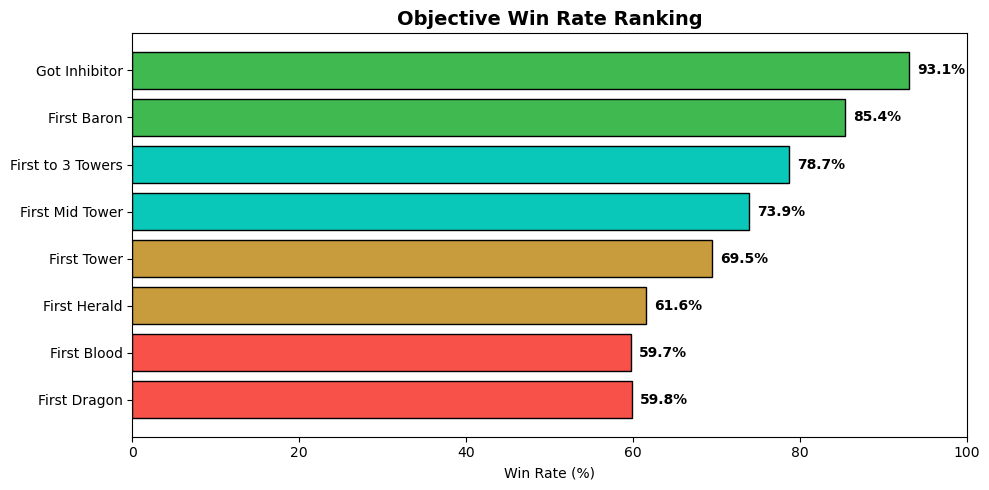

In [67]:
import matplotlib.pyplot as plt

# Calculate win rates for each objective
objs = ["got_inhibitor", "firstbaron", "firsttothreetowers", "firstmidtower",
        "firsttower", "firstherald", "firstblood", "firstdragon"]
labels = ["Got Inhibitor", "First Baron", "First to 3 Towers", "First Mid Tower",
          "First Tower", "First Herald", "First Blood", "First Dragon"]
win_rates = [df[df[o] == 1]["result"].mean() * 100 for o in objs]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#3FB950" if w >= 80 else "#0AC8B9" if w >= 70 else "#C89B3C" if w >= 60 else "#F85149" for w in win_rates]
ax.barh(labels[::-1], win_rates[::-1], color=colors[::-1], edgecolor="black")
ax.set_xlabel("Win Rate (%)")
ax.set_title("Objective Win Rate Ranking", fontsize=14, fontweight="bold")
ax.set_xlim(0, 100)
for i, v in enumerate(win_rates[::-1]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

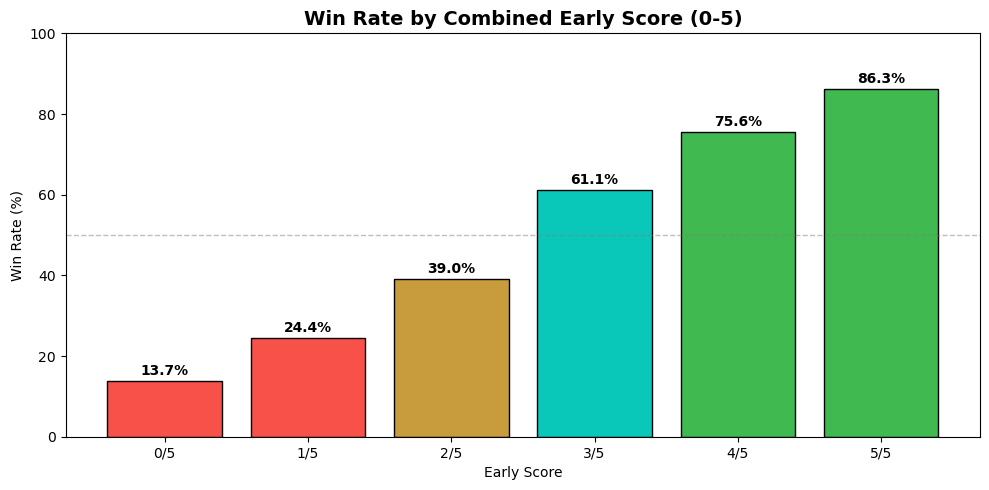

In [68]:
score_wr = df.groupby("early_score")["result"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#F85149", "#F85149", "#C89B3C", "#0AC8B9", "#3FB950", "#3FB950"]
ax.bar([f"{int(s)}/5" for s in score_wr.index], score_wr.values, color=colors, edgecolor="black")
ax.set_ylabel("Win Rate (%)")
ax.set_xlabel("Early Score")
ax.set_title("Win Rate by Combined Early Score (0-5)", fontsize=14, fontweight="bold")
ax.set_ylim(0, 100)
for i, v in enumerate(score_wr.values):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

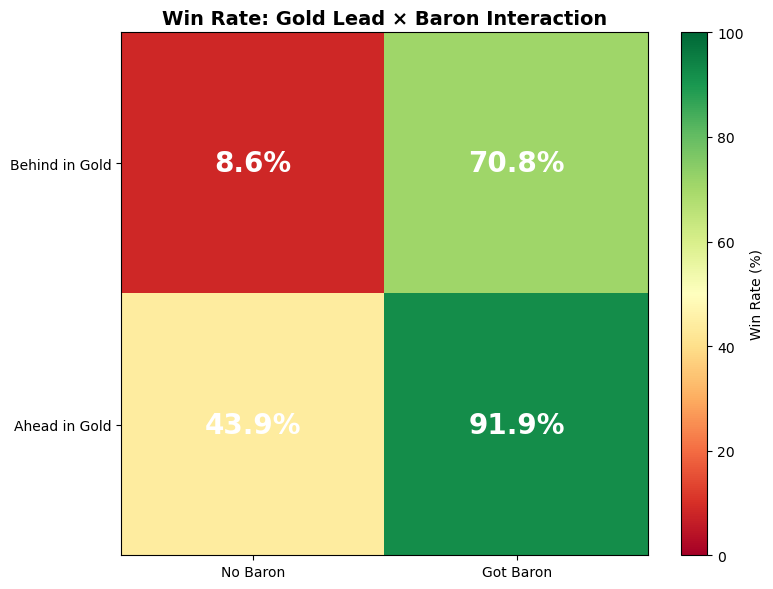

In [69]:
matrix = df.groupby(["gold_lead", "firstbaron"])["result"].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Baron", "Got Baron"])
ax.set_yticklabels(["Behind in Gold", "Ahead in Gold"])
ax.set_title("Win Rate: Gold Lead × Baron Interaction", fontsize=14, fontweight="bold")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matrix.values[i,j]:.1f}%", ha="center", va="center",
                fontsize=20, fontweight="bold", color="white")

plt.colorbar(im, ax=ax, label="Win Rate (%)")
plt.tight_layout()
plt.show()

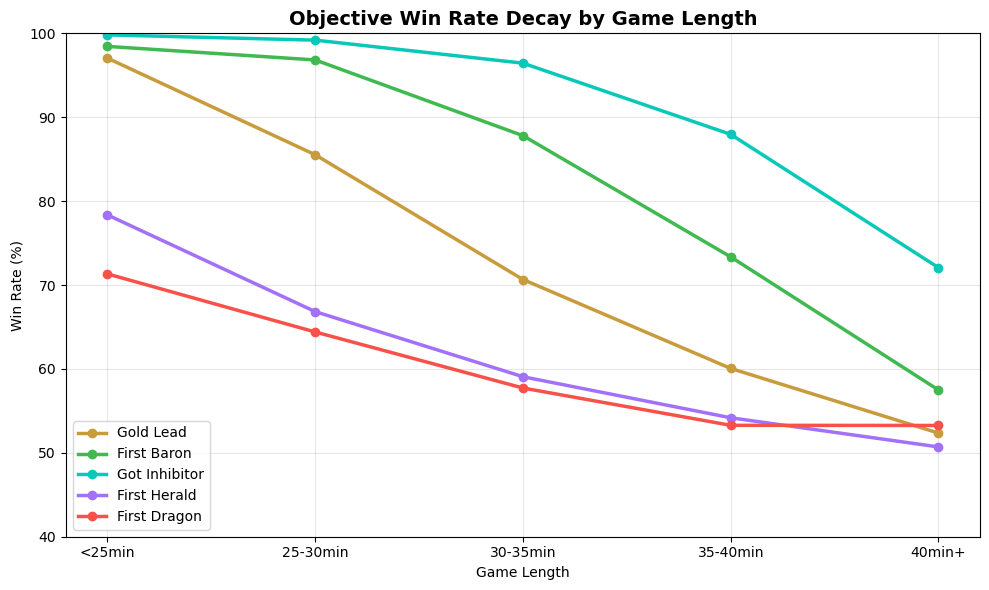

In [70]:
length_order = ["<25min", "25-30min", "30-35min", "35-40min", "40min+"]
objs_to_plot = ["gold_lead", "firstbaron", "got_inhibitor", "firstherald", "firstdragon"]
labels_plot = ["Gold Lead", "First Baron", "Got Inhibitor", "First Herald", "First Dragon"]
colors_plot = ["#C89B3C", "#3FB950", "#0AC8B9", "#A371F7", "#F85149"]

fig, ax = plt.subplots(figsize=(10, 6))
for obj, lbl, col in zip(objs_to_plot, labels_plot, colors_plot):
    vals = [df[(df["length_bucket"] == b) & (df[obj] == 1)]["result"].mean() * 100 for b in length_order]
    ax.plot(length_order, vals, marker="o", linewidth=2.5, label=lbl, color=col)

ax.set_ylabel("Win Rate (%)")
ax.set_xlabel("Game Length")
ax.set_title("Objective Win Rate Decay by Game Length", fontsize=14, fontweight="bold")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
ax.set_ylim(40, 100)
plt.tight_layout()
plt.show()

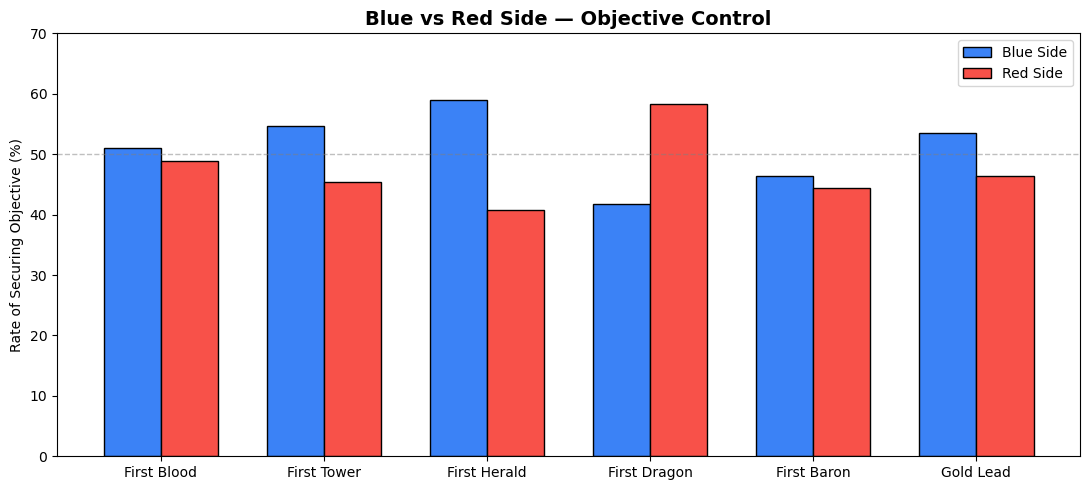

In [71]:
side_obj = df.groupby("side")[["firstblood", "firsttower", "firstherald",
                                "firstdragon", "firstbaron", "gold_lead"]].mean() * 100
labels_side = ["First Blood", "First Tower", "First Herald", "First Dragon", "First Baron", "Gold Lead"]

x = range(len(labels_side))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - width/2 for i in x], side_obj.loc["Blue"].values, width, label="Blue Side", color="#3B82F6", edgecolor="black")
ax.bar([i + width/2 for i in x], side_obj.loc["Red"].values, width, label="Red Side", color="#F85149", edgecolor="black")

ax.set_ylabel("Rate of Securing Objective (%)")
ax.set_title("Blue vs Red Side — Objective Control", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels_side)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend()
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()

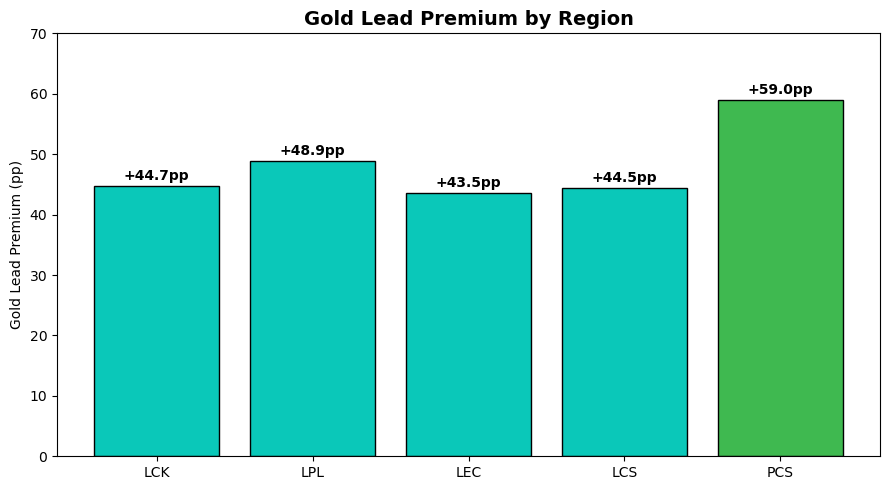

In [72]:
regions = ["LCK", "LPL", "LEC", "LCS", "PCS"]
premiums = []
for r in regions:
    sub = df_main[df_main["league"] == r]
    with_g = sub[sub["gold_lead"] == 1]["result"].mean() * 100
    without_g = sub[sub["gold_lead"] == 0]["result"].mean() * 100
    premiums.append(with_g - without_g)

fig, ax = plt.subplots(figsize=(9, 5))
colors_r = ["#0AC8B9" if p < 50 else "#3FB950" for p in premiums]
ax.bar(regions, premiums, color=colors_r, edgecolor="black")
ax.set_ylabel("Gold Lead Premium (pp)")
ax.set_title("Gold Lead Premium by Region", fontsize=14, fontweight="bold")
ax.set_ylim(0, 70)
for i, v in enumerate(premiums):
    ax.text(i, v + 1, f"+{v:.1f}pp", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

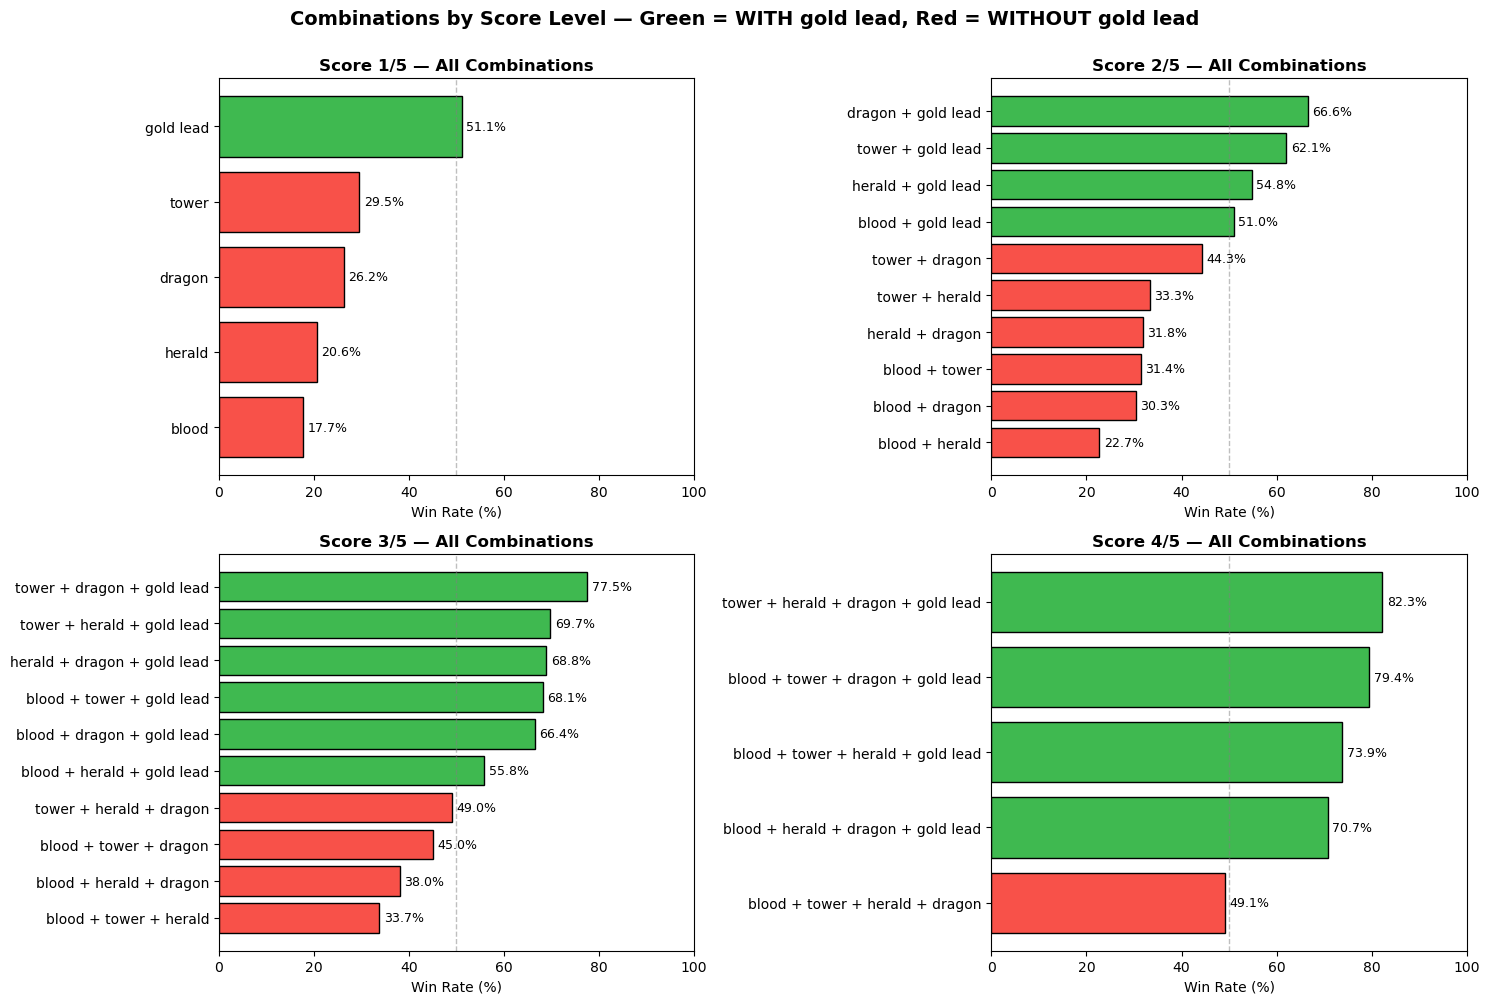

In [73]:
import matplotlib.pyplot as plt

indicators = ["firstblood", "firsttower", "firstherald", "firstdragon", "gold_lead"]

# Build a list of all combinations and their win rates
combo_data = []
for score in [1, 2, 3, 4]:
    sub = df[df["early_score"] == score].copy()
    sub["combo"] = sub[indicators].apply(
        lambda row: " + ".join([c.replace("first", "").replace("_lead", " lead") 
                                 for c in indicators if row[c] == 1]), axis=1)
    
    combo_stats = sub.groupby("combo").agg(
        games=("result", "count"),
        win_rate=("result", "mean")
    ).reset_index()
    combo_stats["score"] = score
    combo_stats["has_gold"] = combo_stats["combo"].str.contains("gold lead")
    combo_data.append(combo_stats)

# Plot — 4 subplots (one per score level)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (score, data) in enumerate(zip([1, 2, 3, 4], combo_data)):
    ax = axes[i]
    data_sorted = data.sort_values("win_rate", ascending=True)
    
    # Color: green if has gold_lead, red if not
    colors = ["#3FB950" if g else "#F85149" for g in data_sorted["has_gold"]]
    
    ax.barh(data_sorted["combo"], data_sorted["win_rate"] * 100, color=colors, edgecolor="black")
    ax.set_xlabel("Win Rate (%)")
    ax.set_title(f"Score {score}/5 — All Combinations", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 100)
    ax.axvline(50, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    
    # Add win rate labels
    for j, v in enumerate(data_sorted["win_rate"] * 100):
        ax.text(v + 1, j, f"{v:.1f}%", va="center", fontsize=9)

# Add a legend that explains the color
fig.suptitle("Combinations by Score Level — Green = WITH gold lead, Red = WITHOUT gold lead", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

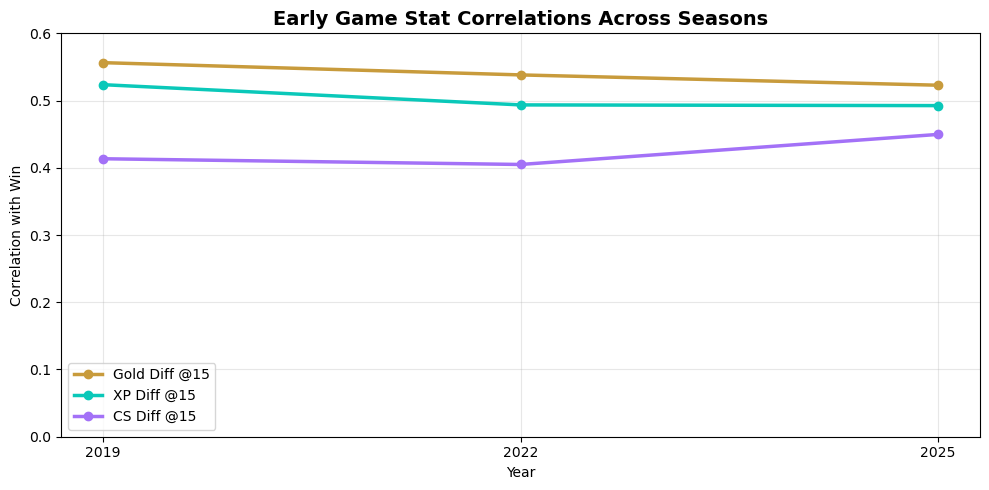

In [74]:
import matplotlib.pyplot as plt

years = sorted(df["year"].unique())
gold_corr = [df[df["year"] == y][["golddiffat15", "result"]].corr().iloc[0, 1] for y in years]
xp_corr = [df[df["year"] == y][["xpdiffat15", "result"]].corr().iloc[0, 1] for y in years]
cs_corr = [df[df["year"] == y][["csdiffat15", "result"]].corr().iloc[0, 1] for y in years]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, gold_corr, marker="o", linewidth=2.5, label="Gold Diff @15", color="#C89B3C")
ax.plot(years, xp_corr, marker="o", linewidth=2.5, label="XP Diff @15", color="#0AC8B9")
ax.plot(years, cs_corr, marker="o", linewidth=2.5, label="CS Diff @15", color="#A371F7")
ax.set_xticks(years)
ax.set_ylabel("Correlation with Win")
ax.set_xlabel("Year")
ax.set_title("Early Game Stat Correlations Across Seasons", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

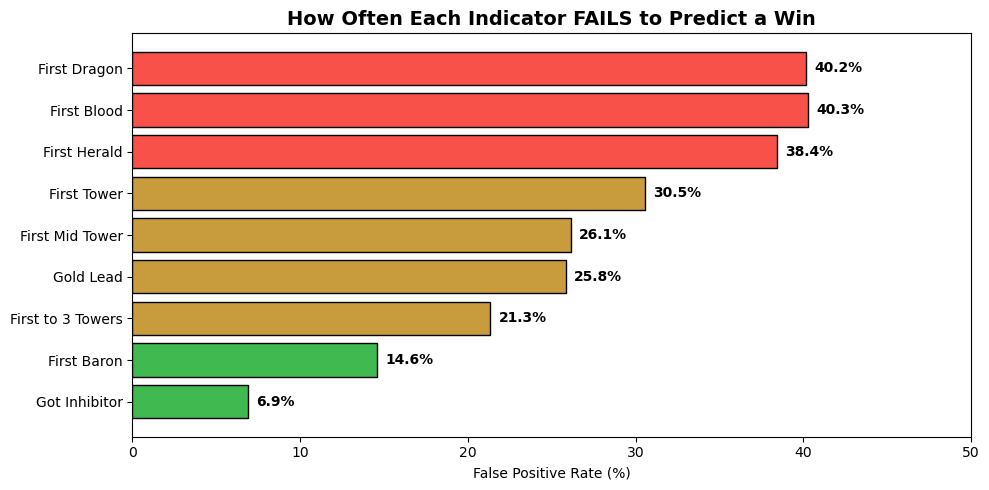

In [75]:
import matplotlib.pyplot as plt

indicators = ["firstdragon", "firstblood", "firstherald", "firsttower",
              "firstmidtower", "gold_lead", "firsttothreetowers", "firstbaron", "got_inhibitor"]
labels = ["First Dragon", "First Blood", "First Herald", "First Tower", "First Mid Tower",
          "Gold Lead", "First to 3 Towers", "First Baron", "Got Inhibitor"]

fp_rates = []
for col in indicators:
    had = df[df[col] == 1]
    fp = had[had["result"] == 0]
    fp_rates.append(len(fp) / len(had) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#F85149" if f > 35 else "#C89B3C" if f > 20 else "#3FB950" for f in fp_rates]
ax.barh(labels[::-1], fp_rates[::-1], color=colors[::-1], edgecolor="black")
ax.set_xlabel("False Positive Rate (%)")
ax.set_title("How Often Each Indicator FAILS to Predict a Win", fontsize=14, fontweight="bold")
ax.set_xlim(0, 50)
for i, v in enumerate(fp_rates[::-1]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

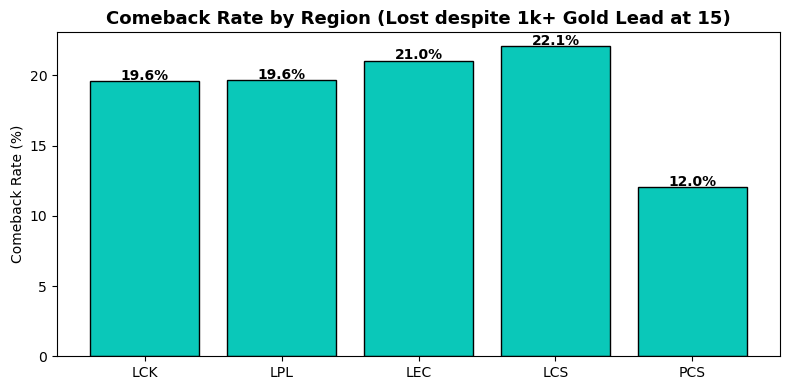

In [76]:
regions = ["LCK", "LPL", "LEC", "LCS", "PCS"]
rates = []
for r in regions:
    sub = df_main[df_main["league"] == r]
    teams_ahead = sub[sub["golddiffat15"] > 1000]
    comebacks = teams_ahead[teams_ahead["result"] == 0]
    rates.append(len(comebacks) / len(teams_ahead) * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(regions, rates, color="#0AC8B9", edgecolor="black")
ax.set_ylabel("Comeback Rate (%)")
ax.set_title("Comeback Rate by Region (Lost despite 1k+ Gold Lead at 15)", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(rates) + 1)
for i, v in enumerate(rates):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()